In [2]:
"""Analyze public app store reviews of DB Navigator to identify user satisfaction, recurring complaints, and factors influencing user engagement. Apply text mining and sentiment analysis to extract actionable insights that can guide the design of user-centered digital public services."""
# =========================================================
# DB NAVIGATOR APP REVIEW ANALYSIS
#
# Research Goal:
# Analyze public app store reviews of DB Navigator to identify
# user satisfaction, recurring complaints, feature requests,
# and factors influencing user engagement.
#
# Apply text mining and sentiment analysis to extract
# actionable insights that can guide the design and
# improvement of user-centered digital public services.
#
# Research Questions:
# - What aspects of DB Navigator do users value most?
# - What are the most common sources of user frustration?
# - Which topics have the greatest impact on user satisfaction?
#
# Dataset:
# Public Google Play Store reviews of DB Navigator
# (App ID: de.hafas.android.db)
#
# =========================================================

'Analyze public app store reviews of DB Navigator to identify user satisfaction, recurring complaints, and factors influencing user engagement. Apply text mining and sentiment analysis to extract actionable insights that can guide the design of user-centered digital public services.'

In [ ]:
# =========================================================
# 1. INSTALL REQUIRED LIBRARIES
#
# Run this only once.
# These libraries are used for:
#
# - data analysis
# - visualization
# - text mining
# - sentiment analysis
# - topic modeling
#
# =========================================================
#!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud textblob

# =========================================================
# 2. IMPORT LIBRARIES
#
# pandas      -> data handling
# numpy       -> numerical operations
# matplotlib  -> plotting
# seaborn     -> better visualizations
# Counter     -> count word frequencies
# WordCloud   -> generate word clouds
# sklearn     -> topic modeling
# TextBlob    -> sentiment analysis
# nltk        -> stopwords
# re          -> text cleaning with regex
#
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from collections import Counter
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from textblob import TextBlob

import nltk
from nltk.corpus import stopwords

import re

# =========================================================
# 3. DOWNLOAD NLTK STOPWORDS
#
# Stopwords are common words like:
# "und", "oder", "der", "die"
#
# These words do not carry much meaning
# for text mining.
#
# =========================================================

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/amir/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
# =========================================================
# 4. LOAD DATASET
#
# Read the CSV file containing app reviews.
#
# =========================================================

reviews = pd.read_csv("data/db_navigator_reviews.csv")

In [5]:
# =========================================================
# 5. VIEW FIRST ROWS
#
# Quick inspection of the dataset.
#
# head() shows the first 5 rows.
#
# =========================================================

reviews.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,14fec7bb-b9d0-42ec-a449-ae767dafc58e,Oliver Bschor,https://play-lh.googleusercontent.com/a/ACg8oc...,völlig unübersichtliche Bedienoberfläche,1,0,26.11.0,2026-06-27 15:08:36,NaN,NaN,26.11.0
1,f7f95b83-a988-4d69-82b3-e4a63bd34aef,Heike Veit,https://play-lh.googleusercontent.com/a-/ALV-U...,Gute Bedienbarkeit.,5,0,26.11.0,2026-06-27 12:41:37,NaN,NaN,26.11.0
2,8f966e81-dca5-4076-87b7-42e1a9cf69e1,Thomas Lichtenfeld,https://play-lh.googleusercontent.com/a/ACg8oc...,Soweit ok.,4,0,NaN,2026-06-27 12:01:03,NaN,NaN,NaN
3,a5275f68-dc30-46c6-916e-711fe01fe51c,Gerd Urban,https://play-lh.googleusercontent.com/a-/ALV-U...,"Einloggen nicht möglich, Seite öffnet sich nic...",1,0,26.11.0,2026-06-27 11:49:13,NaN,NaN,26.11.0
4,8346cb9e-7ab6-4d92-8664-0b102d04eb98,R Manz,https://play-lh.googleusercontent.com/a/ACg8oc...,An sich hat bisher immer alles gut funktionier...,3,0,26.11.0,2026-06-27 10:41:27,NaN,NaN,26.11.0


In [6]:
# =========================================================
# 6. BASIC DATASET INFORMATION
#
# - shape      -> number of rows and columns
# - columns    -> dataset column names
# - isnull()   -> missing values
#
# =========================================================

print("Dataset Shape:")
print(reviews.shape)

print("\nColumns:")
print(reviews.columns)

print("\nMissing Values:")
print(reviews.isnull().sum())
reviews['score'].value_counts().sort_index()

Dataset Shape:
(773, 6)

Columns:
Index(['review_id', 'score', 'content', 'date', 'version', 'thumbs_up'], dtype='str')

Missing Values:
review_id     0
score         0
content       0
date          0
version      50
thumbs_up     0
dtype: int64


score
1    108
2     51
3     86
4    127
5    401
Name: count, dtype: int64

In [7]:
# =========================================================
# 7. CLEAN DATASET
#
# Steps:
#
# 1. Remove rows with missing reviews (skipped)
# 2. Convert reviews to string
# 3. Remove duplicate reviews
#
# =========================================================

#reviews['content'] = reviews['content'].astype(str)

reviews = reviews.drop_duplicates(subset=['content'])

# =========================================================
# 8. LOAD GERMAN STOPWORDS
#
# Stopwords are removed because they appear
# very often but provide little information.
#
# Custom stopwords are added manually.
#
# =========================================================

stop_words = set(stopwords.words('german'))

custom_stopwords = {

    'app',
    'apps',
    'stadt',
    'sehr',
    'mehr',
    'schon',
    'einfach',

    # generic filler words
    'gut',
    'super',
    'leider',
    'immer',
    'mal',
    'gibt',
    'wurde',
    'eigentlich',
    'einfach',
    'wirklich',
    'schöne',
    'schön',
    'danke',
    'finde',
    'klappt',
    'wäre',
    'sache'
}

stop_words.update(custom_stopwords)

stop_words.update(custom_stopwords)

# =========================================================
# 9. TEXT PREPROCESSING FUNCTION
#
# This function cleans review text.
#
# Steps:
#
# 1. lowercase text
# 2. remove urls
# 3. remove numbers
# 4. remove punctuation
# 5. tokenize words
# 6. remove stopwords
#
# =========================================================

def preprocess_text(text):

    # convert text to lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\\S+', '', text)

    # remove numbers
    text = re.sub(r'\\d+', '', text)

    # remove punctuation/special characters
    text = re.sub(r'[^a-zA-ZäöüÄÖÜß\s]', '', text)

    # split text into words
    tokens = text.split()

    # remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # join words back into text
    return " ".join(tokens)

# =========================================================
# 10. APPLY TEXT CLEANING
#
# Create a new column:
#
# clean_text
#
# containing cleaned reviews.
#
# =========================================================

reviews['clean_text'] = reviews['content'].apply(preprocess_text)

# =========================================================
# 11. COMPARE ORIGINAL VS CLEANED TEXT
#
# Useful to verify preprocessing quality.
#
# =========================================================

reviews[['content', 'clean_text']].head()

,content,clean_text
0,"einfach zu handhaben, habe die App wiederholt ...",handhaben wiederholt verwendet gute reaktionen...
1,Etwas unübersichtlich aber ansich eine gute Sa...,unübersichtlich ansich gute
2,Tolle und einfache App,tolle einfache
3,"Sehr gute App, seitdem unsere Straße sauber ist.",gute seitdem straße sauber
4,Kommen die Meldungen wirklich in der betroffen...,kommen meldungen betroffenen meldungen zwei mo...


In [8]:
# =========================================================
# 12. DEFINE FEATURE KEYWORDS
#
# Manually define important smart city features.
#
# These keywords help identify:
#
# - usability issues
# - technical problems
# - engagement features
# - citizen expectations
# - municipality response quality
#
# The categories are later used to measure
# how frequently users discuss each topic.
#
# =========================================================

feature_keywords = {

    # -----------------------------------------------------
    # USER EXPERIENCE / USABILITY
    # -----------------------------------------------------
    'Usability': [

        'übersichtlich',
        'bedienung',
        'benutzerfreundlich',
        'einfach',
        'simpel',
        'unkompliziert',
        'verständlich',
        'klar',
        'intuitiv',
        'nutzung'
    ],

    # -----------------------------------------------------
    # TECHNICAL PROBLEMS / BUGS
    # -----------------------------------------------------
    'Bug Reports': [

        'bug',
        'bugs',
        'fehler',
        'absturz',
        'abgestürzt',
        'langsam',
        'hängt',
        'hängen',
        'funktioniert',
        'funktioniertnicht',
        'problem',
        'probleme',
        'update',
        'lade',
        'crash',
        'störung'
    ],

    # -----------------------------------------------------
    # NOTIFICATIONS / COMMUNICATION
    # -----------------------------------------------------
    'Notifications': [

        'benachrichtigung',
        'benachrichtigungen',
        'push',
        'meldung',
        'meldungen',
        'info',
        'informationen',
        'hinweis',
        'updates'
    ],

    # -----------------------------------------------------
    # STATUS TRACKING / TRANSPARENCY
    # -----------------------------------------------------
    'Tracking': [

        'status',
        'tracking',
        'verfolgen',
        'bearbeitet',
        'erledigt',
        'offen',
        'geschlossen',
        'behoben',
        'bearbeitung',
        'fortschritt'
    ],

    # -----------------------------------------------------
    # RESPONSE TIME / MUNICIPALITY PROCESSING
    # -----------------------------------------------------
    'Response Time': [

        'schnell',
        'langsam',
        'zeit',
        'dauer',
        'tage',
        'wochen',
        'antwort',
        'reagiert',
        'bearbeitung',
        'zeitnah',
        'warten'
    ],

    # -----------------------------------------------------
    # REPORTING FUNCTIONALITY
    # -----------------------------------------------------
    'Issue Reporting': [

        'melden',
        'meldung',
        'mängel',
        'mangel',
        'gemeldet',
        'meldungserstellung',
        'foto',
        'bilder',
        'hochladen',
        'standort'
    ],

    # -----------------------------------------------------
    # PERFORMANCE / STABILITY
    # -----------------------------------------------------
    'Performance': [

        'schnell',
        'stabil',
        'instabil',
        'performance',
        'flüssig',
        'reaktion',
        'ladezeit',
        'hängt',
        'langsam'
    ],

    # -----------------------------------------------------
    # DESIGN / INTERFACE
    # -----------------------------------------------------
    'Design': [

        'design',
        'layout',
        'optik',
        'modern',
        'schön',
        'oberfläche',
        'darstellung',
        'ansicht'
    ],

    # -----------------------------------------------------
    # TRUST / TRANSPARENCY
    # -----------------------------------------------------
    'Transparency': [

        'transparent',
        'rückmeldung',
        'feedback',
        'status',
        'information',
        'sichtbar',
        'nachvollziehbar'
    ],

    # -----------------------------------------------------
    # SMART CITY ENGAGEMENT
    # -----------------------------------------------------
    'Citizen Engagement': [

        'beteiligung',
        'bürger',
        'mitmachen',
        'hilfe',
        'verbessern',
        'gemeinschaft',
        'engagement',
        'ideen'
    ]
}

Positive features:

               Feature  Mentions
0           Usability        65
1         Bug Reports       114
2       Notifications        97
3            Tracking       104
4       Response Time       155
5     Issue Reporting       228
6         Performance       101
7              Design         8
8        Transparency        26
9  Citizen Engagement        21


Negative features:

               Feature  Mentions
0           Usability        10
1         Bug Reports        94
2       Notifications        84
3            Tracking        31
4       Response Time        57
5     Issue Reporting       153
6         Performance        23
7              Design         2
8        Transparency        11
9  Citizen Engagement         2


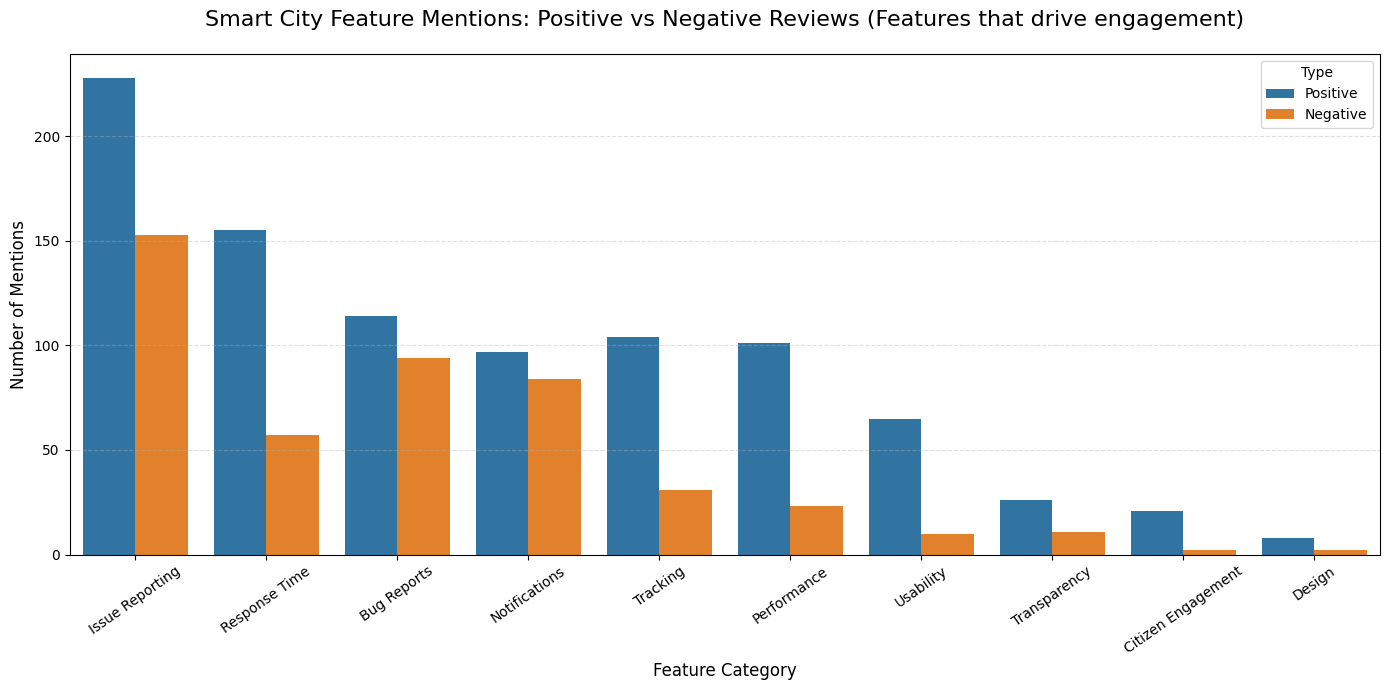

In [9]:
# =========================================================
# FEATURE KEYWORD ANALYSIS
#
# Goal:
# Compare which smart city features are discussed
# in positive vs negative reviews.
#
# This helps identify:
#
# - appreciated features
# - major frustrations
# - high-priority improvements
#
# =========================================================


# =========================================================
# 1. CREATE FEATURE COUNT FUNCTION
# =========================================================

def count_feature_mentions(dataframe, feature_keywords):

    results = {}

    for feature, keywords in feature_keywords.items():

        count = dataframe['clean_text'].apply(

            lambda text: any(
                keyword in text
                for keyword in keywords
            )

        ).sum()

        results[feature] = count

    return pd.DataFrame(
        results.items(),
        columns=['Feature', 'Mentions']
    )


# =========================================================
# 2. POSITIVE REVIEW FEATURE ANALYSIS
#
# Which features appear most often
# in positive reviews?
#
# =========================================================
positive_reviews = reviews[reviews['score'] >= 4]

negative_reviews = reviews[reviews['score'] <= 3]
positive_feature_df = count_feature_mentions(
    positive_reviews,
    feature_keywords
)

print("Positive features:\n\n",positive_feature_df)
# =========================================================
# 3. NEGATIVE REVIEW FEATURE ANALYSIS
#
# Which features appear most often
# in negative reviews?
#
# =========================================================

negative_feature_df = count_feature_mentions(
    negative_reviews,
    feature_keywords
)
print("\n\nNegative features:\n\n",negative_feature_df)

# =========================================================
# COMBINE POSITIVE + NEGATIVE DATA
# =========================================================

positive_feature_df['Type'] = 'Positive'

negative_feature_df['Type'] = 'Negative'

combined_df = pd.concat([
    positive_feature_df,
    negative_feature_df
])

# =========================================================
# SORT FEATURES
# =========================================================

feature_order = combined_df.groupby(
    'Feature'
)['Mentions'].sum().sort_values(
    ascending=False
).index

# =========================================================
# CREATE GROUPED BAR CHART
# =========================================================

plt.figure(figsize=(14,7))

sns.barplot(
    data=combined_df,
    x='Feature',
    y='Mentions',
    hue='Type',
    order=feature_order
)

# chart title
plt.title(
    'Smart City Feature Mentions: Positive vs Negative Reviews (Features that drive engagement)',
    fontsize=16,
    pad=20
)

# axis labels
plt.xlabel('Feature Category', fontsize=12)

plt.ylabel('Number of Mentions', fontsize=12)

# rotate labels
plt.xticks(rotation=35)

# grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.4)

# better spacing
plt.tight_layout()

plt.show()


In [10]:
# =========================================================
# 1. SPLIT REVIEWS BY RATING
#
# Positive reviews:
# ratings 4-5
#
# Negative reviews:
# ratings 1-2-3
#
#
# =========================================================

positive_reviews = reviews[reviews['score'] >= 4]

negative_reviews = reviews[reviews['score'] <= 3]



# =========================================================
# 2. POSITIVE REVIEW TOPIC MODELING
#
# Discover which features users appreciate.
#
# =========================================================

print("\n================ POSITIVE TOPICS ================\n")

# create vector representation (This converts reviews into numbers to be machine readable.)
vectorizer_pos = CountVectorizer(
    max_df=0.9,
    min_df=3,
    stop_words=list(stop_words)
)

X_pos = vectorizer_pos.fit_transform(
    positive_reviews['clean_text']
)

# train LDA (LDA finds hidden discussion themes by looking at: which words frequently appear together in reviews)
lda_pos = LatentDirichletAllocation(
    n_components=4,
    random_state=42
)

lda_pos.fit(X_pos)

# get vocabulary
feature_names_pos = vectorizer_pos.get_feature_names_out()

# display topics
for topic_idx, topic in enumerate(lda_pos.components_):

    print(f"\nPositive Topic {topic_idx + 1}")

    top_words = [
        feature_names_pos[i]
        for i in topic.argsort()[:-6:-1]
    ]

    print(", ".join(top_words))


# =========================================================
# 3. NEGATIVE REVIEW TOPIC MODELING
#
# Discover major frustrations and problems.
#
# =========================================================

print("\n================ NEGATIVE TOPICS ================\n")

# vectorization
vectorizer_neg = CountVectorizer(
    max_df=0.9,
    min_df=3,
    stop_words=list(stop_words)
)

X_neg = vectorizer_neg.fit_transform(
    negative_reviews['clean_text']
)

# train LDA (LDA finds hidden discussion themes by looking at: which words frequently appear together in reviews)
lda_neg = LatentDirichletAllocation(
    n_components=4,
    random_state=42
)

lda_neg.fit(X_neg)

# vocabulary
feature_names_neg = vectorizer_neg.get_feature_names_out()

# display topics
for topic_idx, topic in enumerate(lda_neg.components_):

    print(f"\nNegative Topic {topic_idx + 1}")

    top_words = [
        feature_names_neg[i]
        for i in topic.argsort()[:-6:-1]
    ]

    print(", ".join(top_words))



================ POSITIVE TOPICS ================


Positive Topic 1
schnell, melden, erledigt, mängel, reagiert

Positive Topic 2
funktioniert, top, einwandfrei, mängel, klasse

Positive Topic 3
mängel, meldungen, bearbeitet, behoben, schnell

Positive Topic 4
gute, einfache, meldung, idee, bedienung

================ NEGATIVE TOPICS ================


Negative Topic 1
meldungen, seit, update, angezeigt, melden

Negative Topic 2
meldung, funktioniert, schade, gar, gps

Negative Topic 3
mängel, kategorie, gemeldet, möglich, gute

Negative Topic 4
ab, stürzt, idee, mängel, sterne


In [11]:
"""Analyze public app store reviews of existing smart city and municipal applications from German cities (for example: Mängelmelder). Apply text mining and sentiment analysis to identify what citizens value, what frustrates them, and which features drive engagement. The goal is to extract actionable priorities that Ilmenau can use to guide its own smart city service development and SensBee feature roadmap."""


'Analyze public app store reviews of existing smart city and municipal applications from German cities (for example: Mängelmelder). Apply text mining and sentiment analysis to identify what citizens value, what frustrates them, and which features drive engagement. The goal is to extract actionable priorities that Ilmenau can use to guide its own smart city service development and SensBee feature roadmap.'

# Smart City Review Analysis Findings

=========================================================

Research Topic:

Analyze public app store reviews of existing
smart city and municipal applications from
German cities (for example: Mängelmelder).

Apply text mining and sentiment analysis to:

- identify what citizens value
- identify what frustrates citizens
- identify which features drive engagement

The goal is to extract actionable priorities
that Ilmenau can use to guide its own smart
city service development and the SensBee
feature roadmap.

Dataset:
Maengelmelder app store reviews

=========================================================

# Positive Topics Interpretation (What Citizens Value)

## Positive Topic 1 — Fast Response

**Keywords:**  
- schnell *(fast)*  
- melden *(report)*  
- erledigt *(resolved)*  
- mängel *(issues)*  
- reagiert *(responded)*  

Users value quick issue reporting and fast municipal response times.

---

## Positive Topic 2 — Reliability

**Keywords:**  
- funktioniert *(works)*  
- top *(excellent)*  
- einwandfrei *(flawless)*  
- mängel *(issues)*  
- klasse *(great)*  

Users appreciate reliable functionality and stable performance.

---

## Positive Topic 3 — Issue Resolution

**Keywords:**  
- mängel *(issues)*  
- meldungen *(reports)*  
- bearbeitet *(processed)*  
- behoben *(fixed)*  
- schnell *(fast)*  

Users are satisfied when issues are processed and resolved quickly.

---

## Positive Topic 4 — Usability

**Keywords:**  
- gute *(good)*  
- einfache *(simple)*  
- meldung *(report)*  
- idee *(idea)*  
- bedienung *(usability)*  

Users appreciate simple and intuitive application design.

---

# Negative Topics Interpretation (What Frustrates Citizens)

## Negative Topic 1 — Update and Display Problems

**Keywords:**  
- meldungen *(reports)*  
- seit *(since)*  
- update *(update)*  
- angezeigt *(displayed)*  
- melden *(report)*  

Users report problems related to updates and incorrect display behavior within the application.

---

## Negative Topic 2 — GPS and Functionality Issues

**Keywords:**  
- meldung *(report)*  
- funktioniert *(works)*  
- schade *(unfortunate)*  
- gar *(completely)*  
- gps *(GPS/location service)*  

Users are frustrated by malfunctioning features and GPS-related problems affecting report accuracy.

---

## Negative Topic 3 — Categorization Problems

**Keywords:**  
- mängel *(issues)*  
- kategorie *(category)*  
- gemeldet *(reported)*  
- möglich *(possible)*  
- gute *(good)*  

Users experience difficulties with issue categorization and report classification.

---

## Negative Topic 4 — Crashes and Instability

**Keywords:**  
- ab *(down/off)*  
- stürzt *(crashes)*  
- idee *(idea)*  
- mängel *(issues)*  
- sterne *(ratings)*  

Users report recurring crashes and technical instability that negatively affect user experience.

---

# Features Driving Citizen Engagement

The analysis suggests that citizen engagement in smart city applications is mainly driven by features related to:

- issue reporting,
- response time,
- notifications,
- tracking,
- and application performance.

These categories received the highest number of mentions in both positive and negative reviews, indicating that they strongly influence how citizens interact with municipal applications. The findings suggest that users are highly engaged with features that support communication, transparency, and efficient problem reporting.